In [159]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [160]:
from typing import List
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
import matplotlib.pyplot as plt
sys.path.append('../..')

In [161]:
from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm

In [162]:
NU = 0.01
L_BOUNDS = (0, 0)
U_BOUNDS = (1, 1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [163]:
# NOTE: input is assumed to have requires_grad=True
def pde_res(u: torch.Tensor, v: torch.Tensor, x: torch.Tensor):
    u_grad = grad(u, x, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, x, torch.ones_like(v), create_graph=True)[0]
    u_x, u_y = u_grad[:, 0:1], u_grad[:, 1:2]
    v_x, v_y = v_grad[:, 0:1], v_grad[:, 1:2]

    u_xx = grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, x, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    v_xx = grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
    v_yy = grad(v_y, x, torch.ones_like(v_y), create_graph=True)[0][:, 1:2]
    
    res_a = u * u_x + v * u_y - NU * (u_xx + u_yy)
    res_b = u * v_x + v * v_y - NU * (v_xx + v_yy)
    res_cts = u_x + v_y
    
    return res_a, res_b, res_cts

In [164]:
# define domain context
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    device=device,
    int_sampling='Latin',
    N_int=4_000,
    N_sides=[(0, 0), (0, 0), (0, 0)],
)

domain = cb.CubeDomain(domain_ctx)

In [165]:
def g_D(x):
    return torch.column_stack([
        x[:, 1:2] * x[:, 0:1] * (1 - x[:, 0:1]),
        torch.zeros_like(x[:, 0:1])
    ])

def phi_0(x):
    return x[:, 0:1] * x[:, 1:2] * (1 - x[:, 0:1]) * (1 - x[:, 1:2])

In [166]:
# define model context
model_psi_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    layer = [32, 32, 32, 32],
    u_bounds=U_BOUNDS,
    l_bounds=L_BOUNDS,
    hard_enforce=True,
    constraint_functions=(g_D, phi_0)
)

model_uv = mm.MLPModel(model_psi_ctx).to(device)
optimizer_psi = torch.optim.Adam(model_uv.parameters(), lr=1e-4)
#scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=2_000)

# define model context
# model_omega_ctx = mm.ModelContext(
#     input_dim=3,
#     output_dim=1,
#     layer = [32, 32, 32],
#     u_bounds=U_BOUNDS,
#     l_bounds=L_BOUNDS
# )

# model_omega = mm.MLPModel(model_omega_ctx).to(device)
# optimizer_omega = torch.optim.Adam(model_omega.parameters(), lr=1e-4)

In [167]:
def loss_res_psi(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_pts = domain.interior.requires_grad_(True)
    pde_out_uv = model(pde_pts)
    u, v = pde_out_uv[:, 0:1], pde_out_uv[:, 1:2]

    S_0, S_1, res_cts = pde_res(u, v, pde_pts)
    
    pde_loss = 0.5 * torch.mean(S_0**2 + S_1**2)
    cts_loss = torch.mean(res_cts**2)

    return [pde_loss, 100 * cts_loss]

# def loss_res_omega(model: torch.nn.Module, domain: cb.CubeDomain):
#     pde_pts = domain.interior.requires_grad_(True)
#     pde_out_uv = model_uv(pde_pts)
#     u, v = pde_out_uv[:, 0:1], pde_out_uv[:, 1:2]
#     omega = model(pde_pts)
    
#     res_pde, res_cns, _ = pde_res(u, v, omega, pde_pts)
    
#     pde_loss = torch.mean(res_pde**2)
#     cons_loss = torch.mean(res_cns**2)

#     return [pde_loss, cons_loss]

# def loss_psi_only(model: torch.nn.Module, domain: cb.CubeDomain):
#     int_pts = domain.interior.requires_grad_(True)
#     psi_int = model(int_pts)
#     res,  = pde_res(psi_int, int_pts)
#     pde_loss = torch.mean(res**2)
    
#     top_pts = domain.sides[1][1].requires_grad_(True)
#     psi_top = model(top_pts)
#     psi_grad = grad(psi_top, top_pts, torch.ones_like(psi_top), create_graph=True)[0]
#     u, v = psi_grad[:, 1:2], -psi_grad[:, 0:1]
#     top_loss = torch.mean((u-1)**2 + v**2)
    
#     return [pde_loss, top_loss]



In [168]:
# define training context

train_uv_ctx = train.TrainingContext(
    model=model_uv,
    optimizer=optimizer_psi,
    domain=domain,
    loss_fn=loss_res_psi,
    epochs=20_000,
    monitor_lr=True,
    monitor_gradient=True
)

train_omega_ctx = train.TrainingContext(
    model=model_omega,
    optimizer=optimizer_omega,
    domain=domain,
    loss_fn=loss_res_omega,
    epochs=200,
    monitor_lr=True,
    monitor_gradient=True
)

CYCLES = 400

losses_uv = [[], [[], [], []]]
losses_omega = [[], [[], [], []]]

total_losses, component_losses = train.train_switch_to_lbfgs(train_uv_ctx)

# for cycle in range(CYCLES):    
#     print(f"Starting cycle {cycle+1}/{CYCLES}")
#     print("Holding omega-model const; training uv-model...")
#     model_omega.eval()
#     model_uv.train()
#     uv_total_loss, uv_comp_loss = train.simple_train(train_uv_ctx)
#     losses_uv[0] += uv_total_loss
    
#     for i, comp_loss in enumerate(uv_comp_loss):
#         losses_uv[1][i] += comp_loss
    
#     print("Holding uv-model const; training omega-model...")
#     model_omega.train()
#     model_uv.eval()
#     omega_total_loss, omega_comp_loss = train.simple_train(train_omega_ctx)
#     losses_omega[0] += omega_total_loss
    
#     for i, comp_loss in enumerate(omega_comp_loss):
#         losses_omega[1][i] += comp_loss

Loss at epoch 1 is: 11.194673538208008. Total gradient norm: inf Current learing rate: 0.0001 
Loss at epoch 100 is: 8.132816314697266. Total gradient norm: 9.787628913907369 Current learing rate: 0.0001 
Loss at epoch 200 is: 5.370582580566406. Total gradient norm: 7.993663842413764 Current learing rate: 0.0001 
Loss at epoch 300 is: 4.26556396484375. Total gradient norm: 3.593037988816737 Current learing rate: 0.0001 
Loss at epoch 400 is: 3.8858814239501953. Total gradient norm: 1.9578417837730886 Current learing rate: 0.0001 
Loss at epoch 500 is: 3.455939531326294. Total gradient norm: 2.6348447983418026 Current learing rate: 0.0001 
Loss at epoch 600 is: 3.2561497688293457. Total gradient norm: 2.259492509939327 Current learing rate: 0.0001 
Loss at epoch 700 is: 3.0211374759674072. Total gradient norm: 1.9725431012564951 Current learing rate: 0.0001 
Loss at epoch 800 is: 2.5838305950164795. Total gradient norm: 1.8085212145302048 Current learing rate: 0.0001 
Loss at epoch 900 

KeyboardInterrupt: 

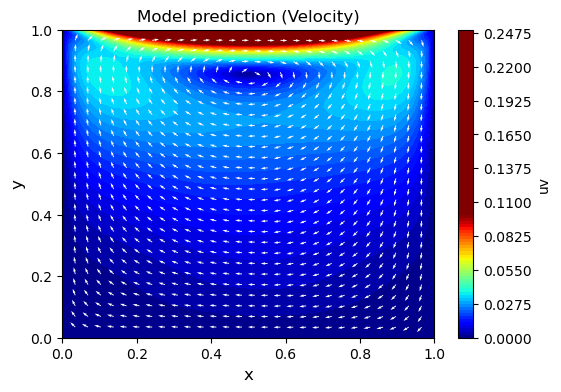

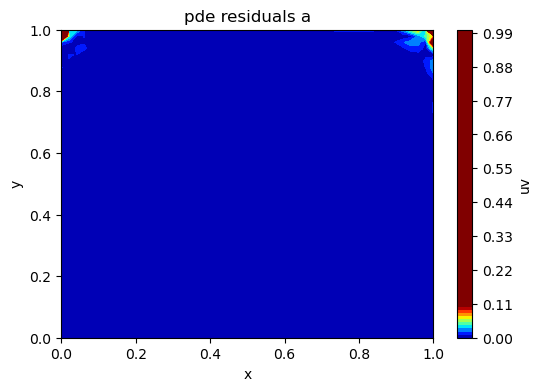

In [ ]:
T_test = 0.5

# define plot context
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names = ['uv'],
    titles= ['Model prediction (Velocity)'],
    device=device,
    vmin=0,
    vmax=0.1,
    patches=[],
    N=50
)

def append_time(x, t):
    return torch.column_stack([x, torch.full_like(x[:, 0:1], t)])

def velocity(x: torch.Tensor) -> torch.Tensor:
    x.requires_grad_(True)
    psi = model_uv(x)[:, 0]
    psi_grad = grad(psi, x, torch.ones_like(psi))[0]
    
    return torch.cat([psi_grad[:, 1:2], -psi_grad[:, 0:1]], dim=1)

utils.plot_vector_field_2d([model_uv], plot_ctx, N=100, n_width=30, n_heigth=30)

def res_helper(x):
    x = x.requires_grad_(True)

    uvp = model_uv(x)
    
    u, v = uvp[:, 0:1], uvp[:, 1:2]
    
    res_a, res_b, res_ct = pde_res(u, v, x)
        
    res = res_a**2 + res_b**2
    res_grad = grad(res, x, torch.ones_like(res))[0][:, 0:2]
    
        
    return torch.abs(res_ct)
    return torch.clamp(torch.norm(res_grad, dim=1), 0.0, 10.0)


plot_ctx.titles = ['pde residuals a']
plot_ctx.vmax = 0.1
utils.plot_function_on_2d_cube([res_helper], plot_ctx)

# plot_ctx.vmin=0
# plot_ctx.vmax=1
# plot_ctx.titles = ['Model prediction (Voricity)']
# plot_ctx.function_names = [r'$\omega$']

# utils.plot_function_on_2d_cube([lambda x: model_omega(append_time(x, T_test))], plot_ctx)

In [ ]:
#print(model_omega(torch.tensor([0.53079011, 0.56524055, 1.0], device=device)))

In [ ]:
def residual_helper(x, t=0.5):
#    x = torch.column_stack([x, torch.full_like(x[:, 0:1], t)])
    x.requires_grad_(True)
    
    uv = model_uv(x)
    u, v = uv[:, 0], uv[:, 1]
        
    print()
        
    return pde_res(u, v, x)

plot_ctx.vmin = 0.0
plot_ctx.vmax = 2

plot_ctx.titles = [f"pde residuum, t={T_test}"]
utils.plot_function_on_2d_cube([lambda x: torch.abs(residual_helper(x, t=T_test)[0])], plot_ctx)

plot_ctx.titles = [f"consistency residuum, t={T_test}"]
utils.plot_function_on_2d_cube([lambda x: torch.abs(residual_helper(x, t=T_test)[1])], plot_ctx)

plot_ctx.titles = [f"continuity residuum, t={T_test}"]
utils.plot_function_on_2d_cube([lambda x: torch.abs(residual_helper(x, t=T_test)[2])], plot_ctx)

ValueError: cannot reshape array of size 6250000 into shape (50,50)

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


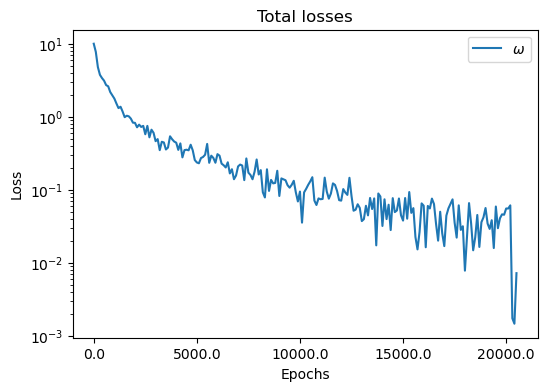

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


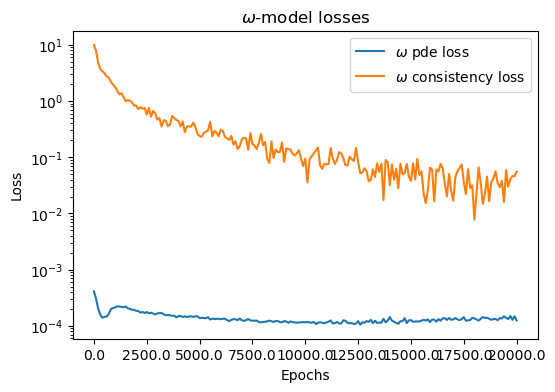

In [ ]:
plot_ctx.x_label = "Epochs"
plot_ctx.y_label = "Loss"

plot_ctx.titles = ["Total losses"]
utils.plot_loss_values({r"$\omega$": total_losses}, plot_ctx)

plot_ctx.titles = [r"$\omega$-model losses"]
utils.plot_loss_values({r"$\omega$ pde loss": component_losses[0], r"$\omega$ consistency loss": component_losses[1]}, plot_ctx)

# plot_ctx.titles = ["uv-model losses"]
# utils.plot_loss_values({r"uv pde loss": losses_uv[1][0], r"uv consistency loss": losses_uv[1][1], r"uv continuity loss": losses_uv[1][2]}, plot_ctx)
